In [2]:
!pip install kaggle


   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   -------------------- ------------------- 1/2 [kaggle]
   ---------------------------------------- 2/2 [kaggle]



In [4]:
#!/bin/bash
!kaggle datasets download salader/dogsvscats

Dataset URL: https://www.kaggle.com/datasets/salader/dogsvscats
License(s): unknown




  0%|          | 0.00/1.06G [00:00<?, ?B/s]
  0%|          | 1.00M/1.06G [00:01<31:30, 604kB/s]
  0%|          | 2.00M/1.06G [00:02<16:40, 1.14MB/s]
  0%|          | 3.00M/1.06G [00:02<12:02, 1.58MB/s]
  0%|          | 4.00M/1.06G [00:02<09:10, 2.07MB/s]
  0%|          | 5.00M/1.06G [00:02<07:40, 2.47MB/s]
  1%|          | 6.00M/1.06G [00:03<06:51, 2.76MB/s]
  1%|          | 7.00M/1.06G [00:03<06:26, 2.94MB/s]
  1%|          | 8.00M/1.06G [00:03<06:21, 2.98MB/s]
  1%|          | 9.00M/1.06G [00:04<05:58, 3.16MB/s]
  1%|          | 10.0M/1.06G [00:04<05:54, 3.19MB/s]
  1%|          | 11.0M/1.06G [00:04<05:34, 3.38MB/s]
  1%|          | 12.0M/1.06G [00:05<05:43, 3.29MB/s]
  1%|          | 13.0M/1.06G [00:05<05:38, 3.33MB/s]
  1%|▏         | 14.0M/1.06G [00:05<05:30, 3.42MB/s]
  1%|▏         | 15.0M/1.06G [00:06<05:33, 3.38MB/s]
  1%|▏         | 16.0M/1.06G [00:06<05:38, 3.32MB/s]
  2%|▏         | 17.0M/1.06G [00:06<06:10, 3.03MB/s]
  2%|▏         | 18.0M/1.06G [00:07<06:14, 3.00MB/s]
  

In [10]:
import zipfile
zip_ref = zipfile.ZipFile('dogsvscats.zip', 'r')
zip_ref.extractall('dogvscat')
zip_ref.close()

In [11]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Flatten
from keras.applications.vgg16 import VGG16

In [12]:
conv_base = VGG16(
    weights='imagenet',
    include_top = False,
    input_shape=(150,150,3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 25s 0us/step


In [13]:
model = Sequential()

model.add(conv_base)
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [14]:
conv_base.trainable = False

In [17]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img

In [18]:
batch_size = 32

train_datagen = ImageDataGenerator(
        rescale=1./255,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
        '/content/train',
        target_size=(150, 150),
        batch_size=batch_size,
        class_mode='binary')

validation_generator = test_datagen.flow_from_directory(
        '/content/test',
        target_size=(150, 150),
        batch_size=batch_size,
        class_mode='binary')

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


In [ ]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
history = model.fit(
        train_generator,
        epochs=10,
        validation_data=validation_generator)

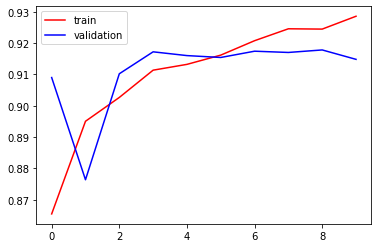

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

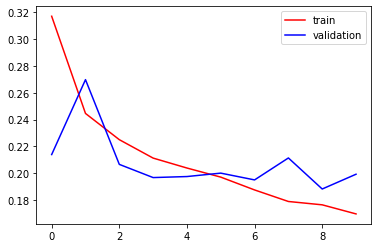

In [ ]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()